# Pre-processing 

#### Filter the signals, downsampling and CMR and save in INTERIM folder (single session)

In [ ]:
%load_ext autoreload
%autoreload 2
from src.preprocessing import extract_and_save_lfp

subject = "Router"
session = "Router_20220211"
extract_and_save_lfp(subject, session, n_jobs=4)

#### Filter (1-300Hz), downsample at 1000 Hz and save (all subjects)

In [ ]:
%load_ext autoreload
%autoreload 2
from src.config import RAW_DATA_DIR
from src.preprocessing import extract_and_save_lfp
from src.io import load_binary_session
import spikeinterface.preprocessing as spr

# Iterate over all subject directories
for subject_dir in RAW_DATA_DIR.iterdir():
    if not subject_dir.is_dir():
        continue
    
    subject = subject_dir.name
    
    # Iterate over all session directories within the current subject
    for session_dir in subject_dir.iterdir():
        if not session_dir.is_dir():
            continue
            
        session = session_dir.name
        print(f"Processing -> Subject: {subject} | Session: {session}")
        
        try:            
            # Execute LFP extraction and saving pipeline
            extract_and_save_lfp(subject, session, n_jobs=4)
            
        except Exception as e:
            print(f"Error processing {subject} - {session}: {e}")

#### Get filtered traces and visualize (single session)

In time

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

from src.io import load_lfp_recording
import spikeinterface.widgets as sw

subject = "Wifi"
session = "Wifi_20210618"
recording_lfp = load_lfp_recording(subject, session, "lfp_1000Hz")

In [ ]:
sw.plot_traces(recording_lfp, time_range=(0, 5), mode='map', backend='ipywidgets', clim=(-20, 20))

In frequency

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Extract 5 seconds of data to achieve a clean 1 Hz frequency resolution
fs = recording_lfp.get_sampling_frequency()
end_frame_5s = int(5 * fs)
traces = recording_lfp.get_traces(start_frame=0, end_frame=end_frame_5s)

# Compute Power Spectral Density using Welch's method 
# nperseg=int(fs) forces the window size to exactly 1 second (1 Hz resolution)
frequencies, psd = welch(traces, fs=fs, nperseg=int(fs), axis=0)

# Average the PSD across all 128 channels to emphasize global common-mode noise
mean_psd = np.mean(psd, axis=1)

# Plot the spectrum focusing on the [0, 150] Hz range
plt.figure(figsize=(10, 5))
plt.semilogy(frequencies, mean_psd, color='black', linewidth=1.2)

# Highlight fundamental power-line frequency and its first harmonic
plt.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50 Hz')
plt.axvline(x=100, color='orange', linestyle=':', alpha=0.7, label='100 Hz')

plt.xlim(0, 150)
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'Power Spectral Density ($\mu V^2$/Hz)')
plt.title('Averaged PSD of Raw Signal')
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Inspect data to select artifacts

In [ ]:
%matplotlib widget
%load_ext autoreload
%autoreload 2
from utils.artifact_inspection import inspect_artifacts
subject = "Wifi"
session = "Wifi_20210618"
inspect_artifacts(subject, session, event_type='steps', offset_uv=200.0)

#### Extract envelopes 

Compute and save envelopes for all frequency bands and save to .npz file (all sessions)

In [ ]:
%load_ext autoreload
%autoreload 2
from src.config import INTERIM_DATA_DIR
from src.preprocessing import extract_and_save_envelopes

# Iterate over all subjects in the interim directory
for subject_dir in INTERIM_DATA_DIR.iterdir():
    if not subject_dir.is_dir():
        continue
        
    subject = subject_dir.name
    
    # Iterate over all sessions for the current subject
    for session_dir in subject_dir.iterdir():
        if not session_dir.is_dir():
            continue
            
        session = session_dir.name
        lfp_folder_name = "lfp_1000Hz"
        
        # Verify that the intermediate LFP data exists before proceeding
        if not (session_dir / lfp_folder_name).exists():
            print(f"Skipping {subject} - {session}: '{lfp_folder_name}' not found.")
            continue
            
        print(f"Extracting envelopes for -> Subject: {subject} | Session: {session}")
        
        try:
            # Execute envelope extraction and saving pipeline
            extract_and_save_envelopes(subject, session)
            print(f"Successfully processed {subject} - {session}")
            
        except Exception as e:
            print(f"Error processing {subject} - {session}: {e}")

Visualization

In [ ]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
from src.plot import plot_interactive_envelopes
subject = "Wifi"
session = "Wifi_20210618"
plot_interactive_envelopes(subject, session, fs=100.0, time_window=(0, 200))

#### Epoching

Epoching for all frequency bands and save to .npz file (all sessions). The file can be loaded as a dict with bands as keys, and each tensor is ntrials x nsamples x ntrials

In [ ]:
%load_ext autoreload
%autoreload 2
from src.config import INTERIM_DATA_DIR, EVENT_SUFFIXES, FS_ENVELOPES
from src.preprocessing import epoch_and_normalize_envelopes

# Iterate over all subjects in the interim directory
for subject_dir in INTERIM_DATA_DIR.iterdir():
    if not subject_dir.is_dir():
        continue
        
    subject = subject_dir.name
    
    # Iterate over all sessions for the current subject
    for session_dir in subject_dir.iterdir():
        if not session_dir.is_dir():
            continue
            
        session = session_dir.name

        for event in EVENT_SUFFIXES.keys():
            
            print(f"Extracting envelopes for -> Subject: {subject} | Session: {session} | Event: {event}")
            epoch_and_normalize_envelopes(subject=subject, session=session, event_type=event, thr_der=3.0, fs=FS_ENVELOPES, max_bad_channels=0.1)

Visualization

In [ ]:
%matplotlib widget
%load_ext autoreload
%autoreload 2
from src.plot import plot_interactive_epochs
subject = "Router"
session = "Router_20220211"
event_type = "grasp"
plot_interactive_epochs(subject, session, event_type)

In [ ]:
%matplotlib widget
%load_ext autoreload
%autoreload 2
from src.plot import plot_spatiotemporal_video
subject = "Router"
session = "Router_20220211"
event_type = "grasp"
label_filter = "your_label_filter"
plot_spatiotemporal_video(subject, session, event_type, "R")

#### Epoching and CWT directly on LFP

In [ ]:
%load_ext autoreload
%autoreload 2
from src.config import INTERIM_DATA_DIR, EVENT_SUFFIXES, FS_ENVELOPES
from src.preprocessing import extract_cwt_epochs

# Iterate over all subjects in the interim directory
for subject_dir in INTERIM_DATA_DIR.iterdir():
    if not subject_dir.is_dir():
        continue
        
    subject = subject_dir.name
    
    # Iterate over all sessions for the current subject
    for session_dir in subject_dir.iterdir():
        if not session_dir.is_dir():
            continue
            
        session = session_dir.name
                    
        for event in EVENT_SUFFIXES.keys():
            print(f"Extracting envelopes for -> Subject: {subject} | Session: {session} | Event: {event}")
            # Execute envelope extraction and saving pipeline
            extract_cwt_epochs(subject=subject, session=session, event_type=event, pad_s=2.0, target_fs=100.0, n_freqs=50)

In [ ]:
%matplotlib widget
%load_ext autoreload
%autoreload 2
from src.plot import plot_average_cwt
subject = "Router"
session = "Router_20220211"
event_type = "steps"
plot_average_cwt(subject, session, event_type)

In [ ]:
%matplotlib widget
%load_ext autoreload
%autoreload 2
from src.plot import plot_interactive_cwt
subject = "Router"
session = "Router_20220211"
event_type = "grasp"
plot_interactive_cwt(subject, session, event_type)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


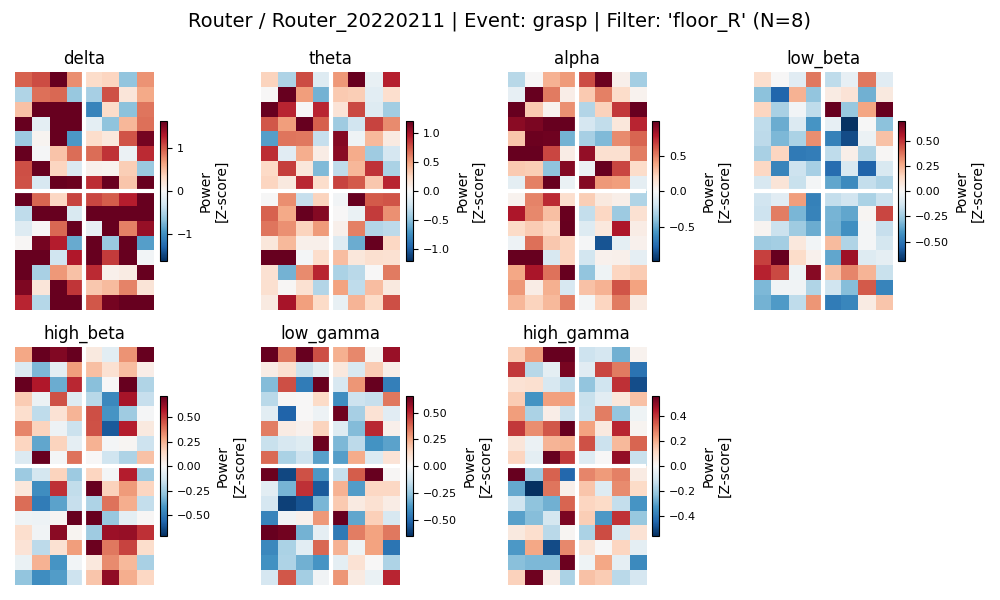

In [2]:
%matplotlib widget
%load_ext autoreload
%autoreload 2
from src.plot import plot_spatiotemporal_cwt_video
subject = "Router"
session = "Router_20220211"
event_type = "grasp"
label_filter = "your_label_filter"
plot_spatiotemporal_cwt_video(subject, session, event_type, "floor_R")